# Lorenz96 metric curves

This notebook mirrors `L63_metric_curves.ipynb` for Lorenz96 and renders only Energy Score (ES) and Rank-Histogram Variance (RHVar). It reads ML results from `save/lorenz96_results` and classic benchmark results from `save/benchmark_lorenz96`.


In [11]:
# Path bootstrap: if running from ./test_notebooks, move to project root
from pathlib import Path
import os

cwd = Path.cwd().resolve()
if cwd.name == 'test_notebooks':
    os.chdir(cwd.parent)
    cwd = Path.cwd().resolve()

print('Current working directory:', cwd)


Current working directory: /home/bhchen/LearnKalmanGain


In [12]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# torch is required to read output_records_*.pt
import torch


In [13]:
# Ensure cwd is project root (where ./save exists)
cwd = Path.cwd().resolve()
if not (cwd / 'save').exists() and (cwd.parent / 'save').exists():
    os.chdir(cwd.parent)

PROJECT_ROOT = Path.cwd().resolve()
SAVE_DIR = PROJECT_ROOT / 'save'
print('PROJECT_ROOT =', PROJECT_ROOT)
print('SAVE_DIR exists =', SAVE_DIR.exists())


PROJECT_ROOT = /home/bhchen/LearnKalmanGain
SAVE_DIR exists = True


In [14]:
# =========================
# User config for Lorenz96 metric curves
# =========================
DATASET = 'lorenz96'
OBS_FN = 'identity'  # default obs_fn for diagnostics printed below
ALL_OBS_FNS = ['identity', 'square', 'arctan']
METRIC_OBS_FN_LIST = ['identity', 'square', 'arctan']
OBS_FN_SIGMA_Y = {
    'identity': 1.0,
    'square': 6.69,
    'arctan': 0.27,
}
SIGMA_Y = OBS_FN_SIGMA_Y[OBS_FN]

AXIS_LABEL_FONTSIZE = 22
TICK_FONTSIZE = 18

VAL_N_LIST = [5, 10, 15, 20, 40, 60, 100]
RESULTS_ROOT = SAVE_DIR / f'{DATASET}_results'
PREFERRED_TUNED_RUNS = {
    'identity': [
        '2026-05-14_13-02lorenz96_1.0_20_60_8192_es_joint_EtE-LRes_tuned_identity',
        '2026-05-14_13-21lorenz96_1.0_20_60_8192_es_joint_CorrTerms_tuned_identity',
        '2026-05-14_16-02lorenz96_1.0_20_60_8192_nl2_joint_EtE-LRes_tuned_identity',
        '2026-05-14_17-12lorenz96_1.0_20_60_8192_nl2_joint_CorrTerms_tuned_identity',
    ],
    'square': [
        '2026-05-14_17-47lorenz96_6.69_20_60_8192_es_joint_EtE-LRes_tuned_square',
        '2026-05-14_17-52lorenz96_6.69_20_60_8192_es_joint_CorrTerms_tuned_square',
        '2026-05-14_17-54lorenz96_6.69_20_60_8192_nl2_joint_EtE-LRes_tuned_square',
        '2026-05-14_17-54lorenz96_6.69_20_60_8192_nl2_joint_CorrTerms_tuned_square',
    ],
    'arctan': [
        '2026-05-14_18-36lorenz96_0.27_20_60_8192_es_joint_EtE-LRes_tuned_arctan',
        '2026-05-14_19-16lorenz96_0.27_20_60_8192_es_joint_CorrTerms_tuned_arctan',
        '2026-05-14_19-29lorenz96_0.27_20_60_8192_nl2_joint_EtE-LRes_tuned_arctan',
        '2026-05-14_19-39lorenz96_0.27_20_60_8192_nl2_joint_CorrTerms_tuned_arctan',
    ],
}
PREFERRED_TUNED_RUN_NAMES = {
    obs_fn: set(run_names)
    for obs_fn, run_names in PREFERRED_TUNED_RUNS.items()
}
BENCHMARK_ROOT_CANDIDATES = [
    PROJECT_ROOT / f'benchmark_{DATASET}',
    SAVE_DIR / f'benchmark_{DATASET}',
]
BENCHMARK_ROOT = next((p for p in BENCHMARK_ROOT_CANDIDATES if p.exists()), BENCHMARK_ROOT_CANDIDATES[-1])
FIG_SAVE_DIR = SAVE_DIR / 'figures' / f'{DATASET}_metric_curves_notebook'
FIG_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('RESULTS_ROOT =', RESULTS_ROOT)
print('BENCHMARK_ROOT =', BENCHMARK_ROOT)
print('FIG_SAVE_DIR =', FIG_SAVE_DIR)
print('METRIC_OBS_FN_LIST =', METRIC_OBS_FN_LIST)


RESULTS_ROOT = /home/bhchen/LearnKalmanGain/save/lorenz96_results
BENCHMARK_ROOT = /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96
FIG_SAVE_DIR = /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook
METRIC_OBS_FN_LIST = ['identity', 'square', 'arctan']


In [15]:
def safe_torch_load(path):
    path = str(path)
    try:
        return torch.load(path, map_location='cpu', weights_only=False)
    except TypeError:
        return torch.load(path, map_location='cpu')


def save_figure_png_pdf(fig, png_path, **savefig_kwargs):
    png_path = Path(png_path)
    pdf_path = png_path.with_suffix('.pdf')
    fig.savefig(png_path, **savefig_kwargs)
    fig.savefig(pdf_path, **savefig_kwargs)
    print('Saved:', png_path)
    print('Saved:', pdf_path)
    return png_path, pdf_path


def _has_any_output_records(folder):
    return any(folder.glob('output_records_*.pt'))


BENCHMARK_METHOD_ORDER = {
    'ESRF': 0,
    'EnKF': 1,
    'LETKF': 2,
    'iEnKS-PertObs': 3,
    'iEnKS-Sqrt': 3,
}
IENKF_SOURCE_METRIC_KEYS = ['mean_es1']


def _record_value(record_dict, key):
    for base in [record_dict.get('test_results', {}), record_dict.get('nn', {}), record_dict]:
        if isinstance(base, dict) and key in base and base[key] is not None:
            try:
                return float(base[key])
            except Exception:
                return np.nan
    return np.nan


def _method_has_nan_metric_values(folder: Path, key_candidates=IENKF_SOURCE_METRIC_KEYS):
    if not folder.exists():
        return True
    for N in VAL_N_LIST:
        rec_path = folder / f'output_records_{N}.pt'
        if not rec_path.exists():
            return True
        record = safe_torch_load(rec_path)
        values = [_record_value(record, key) for key in key_candidates]
        if not any(np.isfinite(v) for v in values):
            return True
    return False


def _select_ienkf_benchmark_dir(sigma_y):
    pertobs_dir = BENCHMARK_ROOT / f'benchmark_{DATASET}_{sigma_y}_iEnKS-PertObs'
    sqrt_dir = BENCHMARK_ROOT / f'benchmark_{DATASET}_{sigma_y}_iEnKS-Sqrt'
    if pertobs_dir.exists() and not _method_has_nan_metric_values(pertobs_dir):
        return pertobs_dir, 'iEnKS-PertObs'
    if sqrt_dir.exists():
        return sqrt_dir, 'iEnKS-Sqrt'
    if pertobs_dir.exists():
        return pertobs_dir, 'iEnKS-PertObs'
    return None, None


EXCLUDED_BENCHMARK_METHODS = {'ESRF'}


def discover_benchmark_dirs(obs_fn: str):
    sigma_y = OBS_FN_SIGMA_Y[obs_fn]
    out = []
    for method in ['ESRF', 'EnKF', 'LETKF']:
        if method in EXCLUDED_BENCHMARK_METHODS:
            continue
        d = BENCHMARK_ROOT / f'benchmark_{DATASET}_{sigma_y}_{method}'
        if not d.is_dir():
            continue
        out.append({
            'label': method,
            'dir': d,
            'kind': 'classic',
            'method': method,
            'obs_fn': obs_fn,
        })

    ienkf_dir, ienkf_source = _select_ienkf_benchmark_dir(sigma_y)
    if ienkf_dir is not None:
        out.append({
            'label': 'IEnKF',
            'dir': ienkf_dir,
            'kind': 'classic',
            'method': ienkf_source,
            'obs_fn': obs_fn,
        })

    out.sort(key=lambda spec: (BENCHMARK_METHOD_ORDER[spec['method']], spec['dir'].name))
    return out


TRAINING_MODEL_ORDER = {'ES': 0, 'NL2': 1}
TRAINING_LOSS_ORDER = {'EtE-LRes': 0, 'CorrTerms': 1}
TRAINING_TUNE_ORDER = {False: 0, True: 1}


def format_training_label(model: str, loss: str) -> str:
    if loss == 'EtE-LRes':
        return f'EtE + {model}'
    return f'{loss}+{model}'


def format_training_run_label(label: str, tuned: bool) -> str:
    return f'{label} ({"tuned" if tuned else "untuned"})'


def parse_training_folder(folder_name: str):
    m = re.search(
        r'_(?P<model>es|nl2)_joint_(?P<loss>EtE-LRes|CorrTerms)(?P<tune_part>None|_tuned)?_(?P<obs_fn>.+)$',
        folder_name,
    )
    if not m:
        return None
    tune_part = m.group('tune_part') or ''
    return {
        'model': m.group('model').upper(),
        'loss': m.group('loss'),
        'obs_fn': m.group('obs_fn'),
        'tuned': tune_part == '_tuned',
    }


def discover_training_dirs(obs_fn: str, root: Path = RESULTS_ROOT, tuned=None, require_outputs: bool = False):
    if (not root.exists()) or (not root.is_dir()):
        return []

    preferred_tuned_names = PREFERRED_TUNED_RUN_NAMES.get(obs_fn, set())
    specs = []
    for d in sorted(root.iterdir()):
        if not d.is_dir():
            continue
        if require_outputs and (not _has_any_output_records(d)):
            continue
        meta = parse_training_folder(d.name)
        if meta is None or meta['obs_fn'] != obs_fn:
            continue
        if tuned is not None and meta['tuned'] != tuned:
            continue
        if meta['tuned'] and preferred_tuned_names and d.name not in preferred_tuned_names:
            continue
        if meta['model'] not in TRAINING_MODEL_ORDER or meta['loss'] not in TRAINING_LOSS_ORDER:
            continue

        label = format_training_label(meta['model'], meta['loss'])
        specs.append({
            'label': label,
            'display_label': format_training_run_label(label, meta['tuned']),
            'dir': d,
            'kind': 'train',
            'model': meta['model'],
            'loss': meta['loss'],
            'obs_fn': obs_fn,
            'tuned': meta['tuned'],
            'tune_label': 'tuned' if meta['tuned'] else 'untuned',
            'has_outputs': _has_any_output_records(d),
        })

    specs.sort(
        key=lambda spec: (
            TRAINING_MODEL_ORDER[spec['model']],
            TRAINING_LOSS_ORDER[spec['loss']],
            TRAINING_TUNE_ORDER[spec['tuned']],
            spec['dir'].name,
        )
    )
    return specs


def build_obs_fn_bundle(obs_fn: str):
    training_specs_all = discover_training_dirs(obs_fn, RESULTS_ROOT, tuned=None, require_outputs=False)
    training_specs_tuned = [spec for spec in training_specs_all if spec['tuned']]
    training_specs_untuned = [spec for spec in training_specs_all if not spec['tuned']]
    return {
        'obs_fn': obs_fn,
        'sigma_y': OBS_FN_SIGMA_Y[obs_fn],
        'benchmark_specs': discover_benchmark_dirs(obs_fn),
        'training_specs': training_specs_tuned,
        'training_specs_all': training_specs_all,
        'training_specs_tuned': training_specs_tuned,
        'training_specs_untuned': training_specs_untuned,
        'training_root': RESULTS_ROOT,
        'benchmark_root': BENCHMARK_ROOT,
    }


def metric_from_record(record_dict, key_candidates):
    candidate_bases = [
        record_dict.get('test_results', {}),
        record_dict.get('nn', {}),
        record_dict,
    ]
    for base in candidate_bases:
        if not isinstance(base, dict):
            continue
        for k in key_candidates:
            if k in base and base[k] is not None:
                try:
                    return float(base[k])
                except Exception:
                    continue
    return np.nan


def collect_metric_table(method_spec, n_values, metric_key_candidates):
    xs, ys = [], []
    for N in n_values:
        rec_path = method_spec['dir'] / f'output_records_{N}.pt'
        if rec_path.exists():
            record = safe_torch_load(rec_path)
            val = metric_from_record(record, metric_key_candidates)
        else:
            val = np.nan
        xs.append(N)
        ys.append(val)
    return np.array(xs, dtype=float), np.array(ys, dtype=float)


In [16]:
obs_fn_bundles = {obs_fn: build_obs_fn_bundle(obs_fn) for obs_fn in ALL_OBS_FNS}

# For benchmark-vs-ML plots, compare classic benchmarks against fine-tuned ML methods.
metric_method_specs = {
    obs_fn: obs_fn_bundles[obs_fn]['benchmark_specs'] + obs_fn_bundles[obs_fn]['training_specs_tuned']
    for obs_fn in METRIC_OBS_FN_LIST
}
ml_method_specs_all = {obs_fn: obs_fn_bundles[obs_fn]['training_specs_all'] for obs_fn in METRIC_OBS_FN_LIST}
ml_method_specs_tuned = {obs_fn: obs_fn_bundles[obs_fn]['training_specs_tuned'] for obs_fn in METRIC_OBS_FN_LIST}
ml_method_specs_untuned = {obs_fn: obs_fn_bundles[obs_fn]['training_specs_untuned'] for obs_fn in METRIC_OBS_FN_LIST}

BASELINE_METHOD_LABEL = 'EtE + ES'

for obs_fn in ALL_OBS_FNS:
    bundle = obs_fn_bundles[obs_fn]
    print('==================================================')
    print(f'obs_fn={obs_fn} | sigma_y={bundle["sigma_y"]}')
    print('Benchmark root:', bundle['benchmark_root'])
    print('Benchmark dirs found:', len(bundle['benchmark_specs']))
    for s in bundle['benchmark_specs']:
        print('  -', s['label'], '|', s['dir'])
    print('Training root:', bundle['training_root'])
    print(
        'Training dirs found:',
        len(bundle['training_specs_all']),
        f'(tuned={len(bundle["training_specs_tuned"])}, untuned={len(bundle["training_specs_untuned"])})',
    )
    for s in bundle['training_specs_all']:
        output_status = 'has output_records' if s['has_outputs'] else 'no output_records yet'
        print('  -', s['display_label'], '|', output_status, '|', s['dir'])
    print('Training dirs used in benchmark comparison:', len(bundle['training_specs_tuned']))


obs_fn=identity | sigma_y=1.0
Benchmark root: /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96
Benchmark dirs found: 3
  - EnKF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_EnKF
  - LETKF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_LETKF
  - IEnKF | /home/bhchen/LearnKalmanGain/save/benchmark_lorenz96/benchmark_lorenz96_1.0_iEnKS-Sqrt
Training root: /home/bhchen/LearnKalmanGain/save/lorenz96_results
Training dirs found: 8 (tuned=4, untuned=4)
  - EtE + ES (untuned) | has output_records | /home/bhchen/LearnKalmanGain/save/lorenz96_results/2026-05-11_21-42lorenz96_1.0_10_60_8192_es_joint_EtE-LResNone_identity
  - EtE + ES (tuned) | has output_records | /home/bhchen/LearnKalmanGain/save/lorenz96_results/2026-05-14_13-02lorenz96_1.0_20_60_8192_es_joint_EtE-LRes_tuned_identity
  - CorrTerms+ES (untuned) | has output_records | /home/bhchen/LearnKalmanGain/save/lorenz96_results/2026-05-11_20-53lorenz96_1.0_10_60_8192_es_jo

## Metric definitions

Only Energy Score (ES) and rank-histogram variance (RHVar) are plotted. Relative improvement is computed for ES against `BASELINE_METHOD_LABEL`, matching the L63 notebook convention: `(method - baseline) / method`, so positive values mean the baseline has a lower ES than that method.


In [17]:
METRIC_SPECS = [
    ('ES', ['mean_es1'], True),
    ('RHVar', ['rank_freq_var'], False),
]

METRIC_FIG_WIDTH = 5.4
METRIC_FIG_HEIGHT = 4.4
METRIC_COMBINED_COLS = 2
METRIC_EQUAL_SPACING_WIDTH_THRESHOLD = 7.5


def _slug(s):
    return re.sub(r'[^A-Za-z0-9]+', '_', str(s)).strip('_')


def use_equal_spaced_metric_x(fig_width):
    return fig_width < METRIC_EQUAL_SPACING_WIDTH_THRESHOLD


def get_metric_plot_x(x_values, fig_width):
    x_values = np.asarray(x_values, dtype=float)
    if use_equal_spaced_metric_x(fig_width):
        return np.arange(len(x_values), dtype=float)
    return x_values


def apply_metric_xaxis_ticks(ax, fig_width):
    if use_equal_spaced_metric_x(fig_width):
        ax.set_xticks(np.arange(len(VAL_N_LIST), dtype=float))
        ax.set_xticklabels([str(v) for v in VAL_N_LIST])
    else:
        ax.set_xticks(VAL_N_LIST)


def _compute_relative_improvement(series, baseline_series):
    series = np.asarray(series, dtype=float)
    baseline_series = np.asarray(baseline_series, dtype=float)
    out = np.full(series.shape, np.nan, dtype=float)
    valid = np.isfinite(series) & np.isfinite(baseline_series) & (np.abs(series) > 1e-12)
    out[valid] = (series[valid] - baseline_series[valid]) / series[valid]
    return out


def _format_metric_axis(ax, ylabel):
    ax.set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=AXIS_LABEL_FONTSIZE)
    apply_metric_xaxis_ticks(ax, METRIC_FIG_WIDTH)
    ax.tick_params(axis='both', labelsize=TICK_FONTSIZE)
    ax.grid(alpha=0.3)


def plot_metric_vs_N(metric_name, metric_keys, obs_fn=None, save=True, show_relative=False):
    obs_fn = obs_fn or OBS_FN
    method_specs = metric_method_specs[obs_fn]

    metric_curves = {}
    for spec in method_specs:
        x, y = collect_metric_table(spec, VAL_N_LIST, metric_keys)
        metric_curves[spec['label']] = {'x': x, 'y': y}

    baseline_curve = metric_curves.get(BASELINE_METHOD_LABEL)
    baseline_y = baseline_curve['y'] if baseline_curve is not None else np.full(len(VAL_N_LIST), np.nan, dtype=float)
    if show_relative and baseline_curve is None:
        print(f'[warn] baseline method missing for obs_fn={obs_fn}: {BASELINE_METHOD_LABEL}')

    if show_relative:
        fig, axes = plt.subplots(
            1,
            2,
            figsize=(METRIC_FIG_WIDTH * METRIC_COMBINED_COLS, METRIC_FIG_HEIGHT),
            sharex=False,
        )
        ax_metric, ax_rel = axes
    else:
        fig, ax_metric = plt.subplots(1, 1, figsize=(METRIC_FIG_WIDTH, METRIC_FIG_HEIGHT), sharex=False)
        ax_rel = None

    for spec in method_specs:
        label = spec['label']
        x = metric_curves[label]['x']
        y = metric_curves[label]['y']
        plot_x = get_metric_plot_x(x, METRIC_FIG_WIDTH)
        valid = np.isfinite(y)
        if np.any(valid):
            (line,) = ax_metric.plot(plot_x[valid], y[valid], marker='o', linewidth=1.8, label=label)
        else:
            print(f'[warn] no valid points for metric={metric_name}, obs_fn={obs_fn}, method={label}')
            (line,) = ax_metric.plot([], [], marker='o', linewidth=1.8, label=label)

        if show_relative:
            rel = _compute_relative_improvement(y, baseline_y)
            rel_valid = np.isfinite(rel)
            if np.any(rel_valid):
                ax_rel.plot(plot_x[rel_valid], rel[rel_valid], marker='o', linewidth=1.8, color=line.get_color())
            else:
                print(f'[warn] no valid rel-improvement points for metric={metric_name}, obs_fn={obs_fn}, method={label}')
                ax_rel.plot([], [], marker='o', linewidth=1.8, color=line.get_color())

    _format_metric_axis(ax_metric, metric_name)
    ax_metric.set_title(obs_fn, fontsize=AXIS_LABEL_FONTSIZE)

    if show_relative:
        _format_metric_axis(ax_rel, 'Relative improvement')
        ax_rel.axhline(0, color='0.5', linewidth=1.0, linestyle='--')
        ax_rel.set_title(f'{obs_fn}: {BASELINE_METHOD_LABEL}', fontsize=AXIS_LABEL_FONTSIZE)

    handles, labels = ax_metric.get_legend_handles_labels()
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), frameon=False, fontsize=14)
    fig.tight_layout(rect=[0, 0, 0.84, 1])

    if save:
        out = FIG_SAVE_DIR / f'L96_{_slug(obs_fn)}_{_slug(metric_name)}_vs_N.png'
        save_figure_png_pdf(fig, out, dpi=180, bbox_inches='tight')
    plt.show()
    return fig, metric_curves


In [18]:
# Individual metric figures are useful for debugging, but disabled by default to save space.
RUN_INDIVIDUAL_METRIC_CURVES = False
individual_metric_curves = {}

if RUN_INDIVIDUAL_METRIC_CURVES:
    for obs_fn in METRIC_OBS_FN_LIST:
        for metric_name, metric_keys, show_relative in METRIC_SPECS:
            fig, curves = plot_metric_vs_N(
                metric_name,
                metric_keys,
                obs_fn=obs_fn,
                save=True,
                show_relative=show_relative,
            )
            individual_metric_curves[(obs_fn, metric_name)] = curves
            plt.close(fig)
else:
    print('Skipping individual metric figures; set RUN_INDIVIDUAL_METRIC_CURVES=True to regenerate them.')


Skipping individual metric figures; set RUN_INDIVIDUAL_METRIC_CURVES=True to regenerate them.


## Combined 3x3 figure

Columns are `identity`, `square`, and `arctan`. Rows are ES, ES relative improvement, and RHVar.


Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_combined_ES_RHVar_3x3.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_combined_ES_RHVar_3x3.pdf


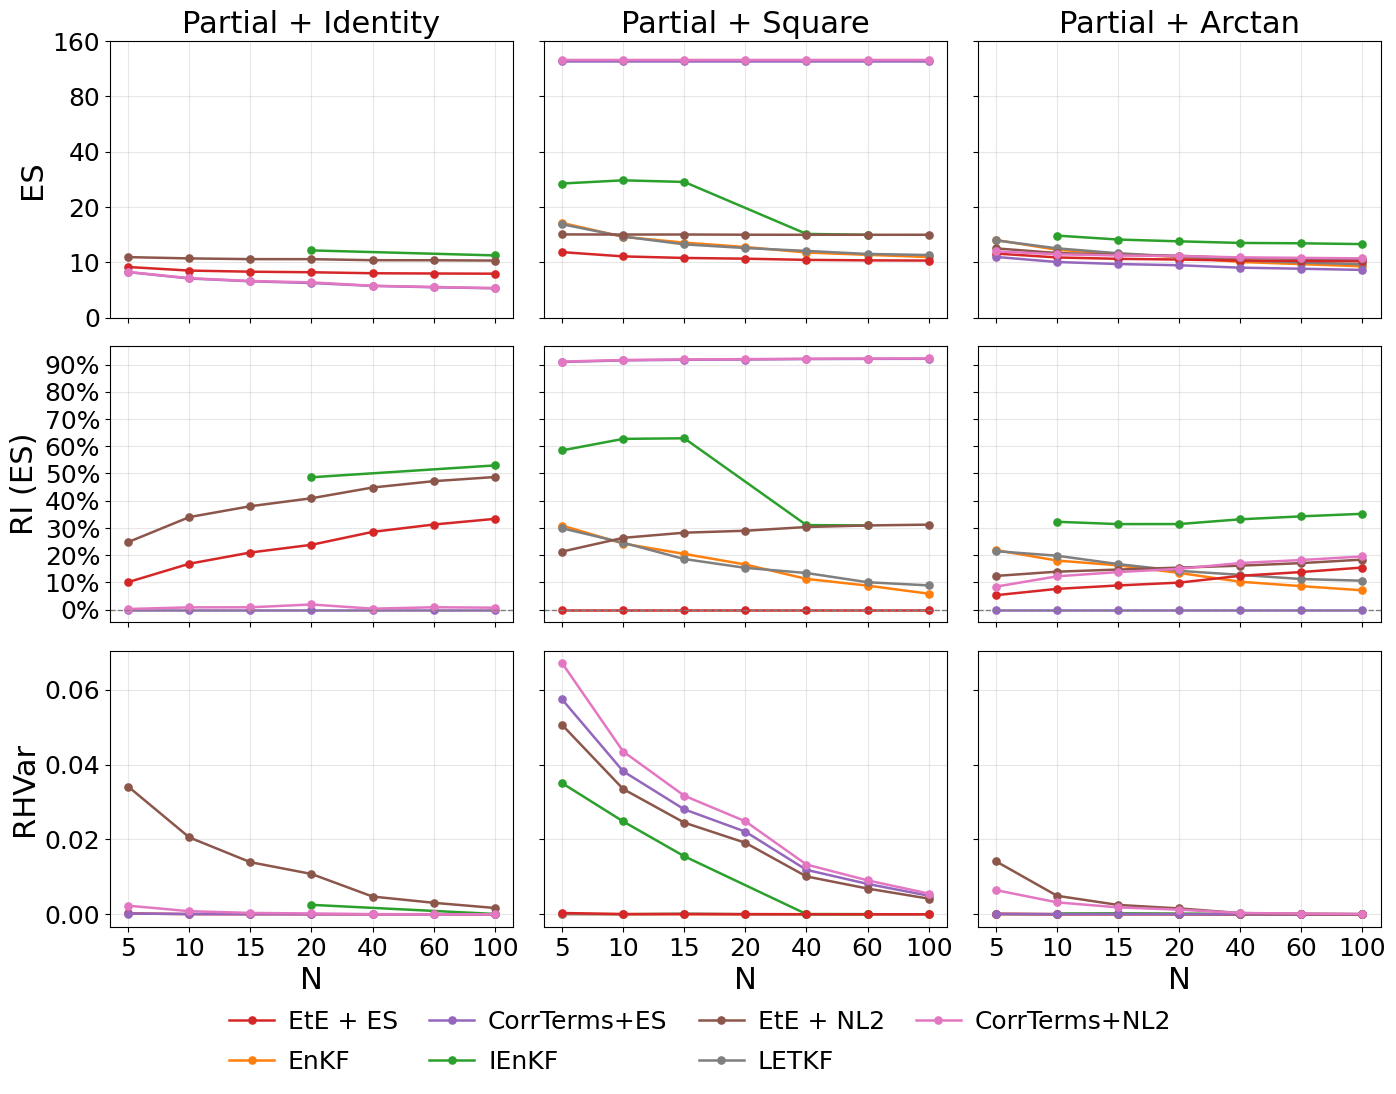

In [19]:
# =========================
# Combined multi-observation 3x3 figure
# =========================
from matplotlib.ticker import MultipleLocator, PercentFormatter

COMBINED_OBS_FN_LIST = ['identity', 'square', 'arctan']
COMBINED_OBS_FN_TITLES = {
    'identity': 'Partial + Identity',
    'square': 'Partial + Square',
    'arctan': 'Partial + Arctan',
}
COMBINED_PANEL_WIDTH = 4.7
COMBINED_PANEL_HEIGHT = 3.6
COMBINED_LINEWIDTH = 1.8
COMBINED_MARKERSIZE = 5.2
COMBINED_LEGEND_FONTSIZE = 18

# Keep the Lorenz63 color assignment for shared methods; LETKF gets the next color.
COMBINED_L63_COLOR_ORDER = [
    'ESRF',
    'EnKF',
    'IEnKF',
    'EtE + ES',
    'CorrTerms+ES',
    'EtE + NL2',
    'CorrTerms+NL2',
    'LETKF',
]
COMBINED_METHOD_ORDER = {
    'ESRF': 0,
    'EnKF': 1,
    'LETKF': 2,
    'IEnKF': 3,
    'EtE + ES': 4,
    'CorrTerms+ES': 5,
    'EtE + NL2': 6,
    'CorrTerms+NL2': 7,
}
COMBINED_LEGEND_ROW_1 = ['EtE + ES', 'CorrTerms+ES', 'EtE + NL2', 'CorrTerms+NL2']
COMBINED_LEGEND_ROW_2 = ['EnKF', 'ESRF', 'IEnKF', 'LETKF']
ES_YTICKS = np.array([0, 10, 20, 40, 80, 160], dtype=float)
ES_YTICK_POSITIONS = np.arange(len(ES_YTICKS), dtype=float)
ES_YLIM = (ES_YTICK_POSITIONS[0], ES_YTICK_POSITIONS[-1])


def _equal_spaced_tick_transform(y, ticks=ES_YTICKS):
    y = np.asarray(y, dtype=float)
    out = np.full(y.shape, np.nan, dtype=float)
    valid = np.isfinite(y)
    if not np.any(valid):
        return out

    positions = np.arange(len(ticks), dtype=float)
    y_valid = y[valid]
    transformed = np.interp(y_valid, ticks, positions)

    below = y_valid < ticks[0]
    if np.any(below):
        transformed[below] = positions[0] + (y_valid[below] - ticks[0]) / (ticks[1] - ticks[0])

    above = y_valid > ticks[-1]
    if np.any(above):
        transformed[above] = positions[-1] + (y_valid[above] - ticks[-1]) / (ticks[-1] - ticks[-2])

    out[valid] = transformed
    return out


def _apply_equal_spaced_es_axis(ax):
    ax.set_ylim(*ES_YLIM)
    ax.set_yticks(ES_YTICK_POSITIONS)
    ax.set_yticklabels([str(int(tick)) for tick in ES_YTICKS])


def _combined_method_specs(obs_fn):
    # metric_method_specs contains classic benchmarks plus tuned ML methods only.
    return list(metric_method_specs[obs_fn])


def _combined_method_labels():
    labels = []
    for obs_fn in COMBINED_OBS_FN_LIST:
        for spec in _combined_method_specs(obs_fn):
            label = spec['label']
            if label not in labels:
                labels.append(label)
    return sorted(labels, key=lambda label: (COMBINED_METHOD_ORDER.get(label, 999), label))


COMBINED_METHOD_LABELS = _combined_method_labels()
COMBINED_COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key().get('color', [])
COMBINED_METHOD_COLORS = {
    label: COMBINED_COLOR_CYCLE[i % len(COMBINED_COLOR_CYCLE)]
    for i, label in enumerate(COMBINED_L63_COLOR_ORDER)
}


def _combined_curves(obs_fn, metric_keys):
    curves = {}
    for spec in _combined_method_specs(obs_fn):
        label = spec['label']
        x, y = collect_metric_table(spec, VAL_N_LIST, metric_keys)
        curves[label] = {'x': x, 'y': y}
    return curves


def _mask_rhvar_where_es_missing(rhvar_curves, es_curves):
    for label, rhvar_curve in rhvar_curves.items():
        es_curve = es_curves.get(label)
        if es_curve is None:
            continue
        es_y = np.asarray(es_curve['y'], dtype=float)
        rhvar_y = np.asarray(rhvar_curve['y'], dtype=float).copy()
        rhvar_y[~np.isfinite(es_y)] = np.nan
        rhvar_curve['y'] = rhvar_y


def _best_es_baseline_y(es_curves):
    candidate_series = []
    for label in ['EtE + ES', 'CorrTerms+ES']:
        if label in es_curves:
            candidate_series.append(np.asarray(es_curves[label]['y'], dtype=float))
    if not candidate_series:
        return np.full(len(VAL_N_LIST), np.nan, dtype=float)
    stacked = np.vstack(candidate_series)
    all_nan = np.all(~np.isfinite(stacked), axis=0)
    baseline_y = np.nanmin(stacked, axis=0)
    baseline_y[all_nan] = np.nan
    return baseline_y


def _relative_improvement_percent(y, baseline_y):
    y = np.asarray(y, dtype=float)
    baseline_y = np.asarray(baseline_y, dtype=float)
    out = np.full(y.shape, np.nan, dtype=float)
    valid = np.isfinite(y) & np.isfinite(baseline_y) & (np.abs(y) > 1e-12)
    out[valid] = 100.0 * (y[valid] - baseline_y[valid]) / y[valid]
    return out


def _legend_labels_two_rows(available_labels):
    row_1 = [label for label in COMBINED_LEGEND_ROW_1 if label in available_labels]
    row_2 = [label for label in COMBINED_LEGEND_ROW_2 if label in available_labels]
    ncol = max(len(row_1), len(row_2), 1)
    labels = []
    for col_idx in range(ncol):
        if col_idx < len(row_1):
            labels.append(row_1[col_idx])
        if col_idx < len(row_2):
            labels.append(row_2[col_idx])
    return labels, ncol


def plot_l96_metric_3x3(out_stem='L96_combined_ES_RHVar_3x3'):
    fig, axes = plt.subplots(
        3,
        len(COMBINED_OBS_FN_LIST),
        figsize=(COMBINED_PANEL_WIDTH * len(COMBINED_OBS_FN_LIST), COMBINED_PANEL_HEIGHT * 3),
        sharex='col',
        sharey='row',
    )

    legend_handles = {}
    es_keys = ['mean_es1']
    rhvar_keys = ['rank_freq_var']

    for col, obs_fn in enumerate(COMBINED_OBS_FN_LIST):
        es_curves = _combined_curves(obs_fn, es_keys)
        rhvar_curves = _combined_curves(obs_fn, rhvar_keys)
        _mask_rhvar_where_es_missing(rhvar_curves, es_curves)
        baseline_y = _best_es_baseline_y(es_curves)

        for label in COMBINED_METHOD_LABELS:
            color = COMBINED_METHOD_COLORS[label]

            if label in es_curves:
                curve = es_curves[label]
                plot_x = get_metric_plot_x(curve['x'], COMBINED_PANEL_WIDTH)
                y = curve['y']
                plot_y = _equal_spaced_tick_transform(y)
                valid = np.isfinite(plot_y)
                if np.any(valid):
                    (line,) = axes[0, col].plot(
                        plot_x[valid],
                        plot_y[valid],
                        marker='o',
                        linewidth=COMBINED_LINEWIDTH,
                        markersize=COMBINED_MARKERSIZE,
                        color=color,
                        label=label,
                    )
                    legend_handles[label] = line

                rel = _relative_improvement_percent(y, baseline_y)
                rel_valid = np.isfinite(rel)
                if np.any(rel_valid):
                    axes[1, col].plot(
                        plot_x[rel_valid],
                        rel[rel_valid],
                        marker='o',
                        linewidth=COMBINED_LINEWIDTH,
                        markersize=COMBINED_MARKERSIZE,
                        color=color,
                    )

            if label in rhvar_curves:
                curve = rhvar_curves[label]
                plot_x = get_metric_plot_x(curve['x'], COMBINED_PANEL_WIDTH)
                y = curve['y']
                valid = np.isfinite(y)
                if np.any(valid):
                    (line,) = axes[2, col].plot(
                        plot_x[valid],
                        y[valid],
                        marker='o',
                        linewidth=COMBINED_LINEWIDTH,
                        markersize=COMBINED_MARKERSIZE,
                        color=color,
                        label=label,
                    )
                    legend_handles[label] = line

        axes[0, col].set_title(COMBINED_OBS_FN_TITLES.get(obs_fn, obs_fn), fontsize=AXIS_LABEL_FONTSIZE)
        axes[1, col].axhline(0, color='0.5', linewidth=1.0, linestyle='--')
        _apply_equal_spaced_es_axis(axes[0, col])
        axes[1, col].yaxis.set_major_locator(MultipleLocator(10))
        axes[1, col].yaxis.set_major_formatter(PercentFormatter(xmax=100.0, decimals=0))
        for row in range(3):
            apply_metric_xaxis_ticks(axes[row, col], COMBINED_PANEL_WIDTH)
            axes[row, col].tick_params(axis='both', labelsize=TICK_FONTSIZE)
            axes[row, col].grid(alpha=0.3)
        axes[2, col].set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)

    axes[0, 0].set_ylabel('ES', fontsize=AXIS_LABEL_FONTSIZE)
    axes[1, 0].set_ylabel('RI (ES)', fontsize=AXIS_LABEL_FONTSIZE)
    axes[2, 0].set_ylabel('RHVar', fontsize=AXIS_LABEL_FONTSIZE)

    legend_labels, legend_ncol = _legend_labels_two_rows(legend_handles.keys())
    legend_handles_ordered = [legend_handles[label] for label in legend_labels]
    fig.legend(
        legend_handles_ordered,
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.02),
        ncol=legend_ncol,
        frameon=False,
        fontsize=COMBINED_LEGEND_FONTSIZE,
        handlelength=1.8,
        handletextpad=0.55,
        columnspacing=1.25,
        labelspacing=0.65,
    )
    fig.tight_layout(rect=[0, 0.06, 1, 1], h_pad=1.0, w_pad=1.2)

    out = FIG_SAVE_DIR / f'{out_stem}.png'
    save_figure_png_pdf(fig, out, dpi=180, bbox_inches='tight')
    plt.show()
    return fig


fig = plot_l96_metric_3x3()
plt.close(fig)


Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_ML_tuned_vs_untuned_ES_2x3.png
Saved: /home/bhchen/LearnKalmanGain/save/figures/lorenz96_metric_curves_notebook/L96_ML_tuned_vs_untuned_ES_2x3.pdf


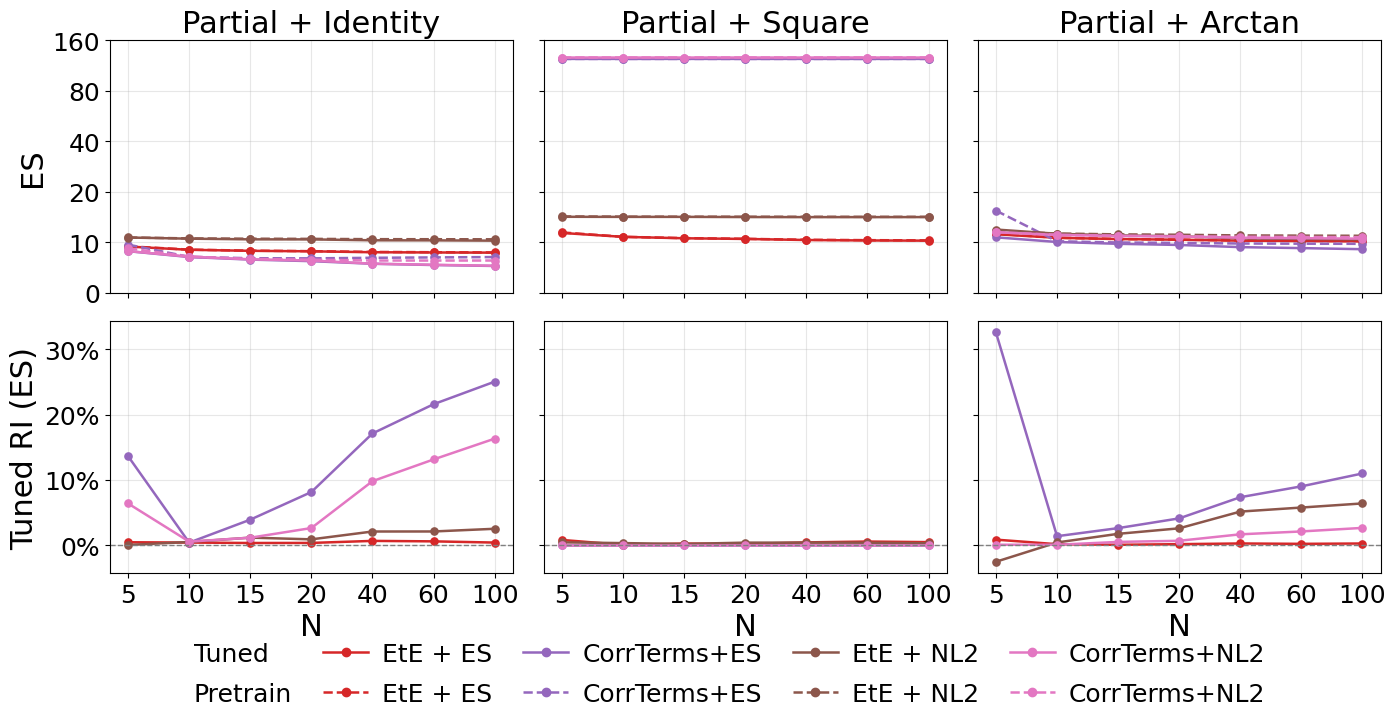

In [20]:
# =========================
# ML tuned-vs-untuned ES comparison (2x3 figure)
# =========================
from matplotlib.lines import Line2D

ML_TUNED_COMPARE_OBS_FN_LIST = ['identity', 'square', 'arctan']
ML_TUNED_COMPARE_METRIC_NAME = 'ES'
ML_TUNED_COMPARE_METRIC_KEYS = ['mean_es1']
ML_TUNED_COMPARE_PANEL_WIDTH = 4.7
ML_TUNED_COMPARE_PANEL_HEIGHT = 3.6
ML_TUNED_COMPARE_LINEWIDTH = 1.8
ML_TUNED_COMPARE_MARKERSIZE = 5.2
ML_TUNED_COMPARE_METHOD_LABELS = ['EtE + ES', 'CorrTerms+ES', 'EtE + NL2', 'CorrTerms+NL2']


def _specs_by_label(specs):
    return {spec['label']: spec for spec in specs}


def _tuned_es_improvement_percent(tuned_y, untuned_y):
    tuned_y = np.asarray(tuned_y, dtype=float)
    untuned_y = np.asarray(untuned_y, dtype=float)
    out = np.full(tuned_y.shape, np.nan, dtype=float)
    valid = np.isfinite(tuned_y) & np.isfinite(untuned_y) & (np.abs(untuned_y) > 1e-12)
    out[valid] = 100.0 * (untuned_y[valid] - tuned_y[valid]) / untuned_y[valid]
    return out


def _collect_tuned_compare_curves(obs_fn):
    tuned_specs = _specs_by_label(ml_method_specs_tuned[obs_fn])
    untuned_specs = _specs_by_label(ml_method_specs_untuned[obs_fn])
    curves = {}
    for label in ML_TUNED_COMPARE_METHOD_LABELS:
        curves[label] = {}
        if label in tuned_specs:
            x, y = collect_metric_table(tuned_specs[label], VAL_N_LIST, ML_TUNED_COMPARE_METRIC_KEYS)
            curves[label]['tuned'] = {'x': x, 'y': y}
        if label in untuned_specs:
            x, y = collect_metric_table(untuned_specs[label], VAL_N_LIST, ML_TUNED_COMPARE_METRIC_KEYS)
            curves[label]['untuned'] = {'x': x, 'y': y}
    return curves


def plot_l96_ml_tuned_vs_untuned_es_2x3(out_stem='L96_ML_tuned_vs_untuned_ES_2x3'):
    fig, axes = plt.subplots(
        2,
        len(ML_TUNED_COMPARE_OBS_FN_LIST),
        figsize=(
            ML_TUNED_COMPARE_PANEL_WIDTH * len(ML_TUNED_COMPARE_OBS_FN_LIST),
            ML_TUNED_COMPARE_PANEL_HEIGHT * 2,
        ),
        sharex='col',
        sharey='row',
    )

    method_handles = {}
    tune_styles = {'tuned': '-', 'untuned': '--'}

    for col, obs_fn in enumerate(ML_TUNED_COMPARE_OBS_FN_LIST):
        curves = _collect_tuned_compare_curves(obs_fn)

        for label in ML_TUNED_COMPARE_METHOD_LABELS:
            color = COMBINED_METHOD_COLORS[label]
            tuned_curve = curves[label].get('tuned')
            untuned_curve = curves[label].get('untuned')

            for tune_label, curve in [('tuned', tuned_curve), ('untuned', untuned_curve)]:
                if curve is None:
                    continue
                plot_x = get_metric_plot_x(curve['x'], ML_TUNED_COMPARE_PANEL_WIDTH)
                y = curve['y']
                plot_y = _equal_spaced_tick_transform(y)
                valid = np.isfinite(plot_y)
                if np.any(valid):
                    (line,) = axes[0, col].plot(
                        plot_x[valid],
                        plot_y[valid],
                        marker='o',
                        linestyle=tune_styles[tune_label],
                        linewidth=ML_TUNED_COMPARE_LINEWIDTH,
                        markersize=ML_TUNED_COMPARE_MARKERSIZE,
                        color=color,
                    )
                    method_handles[label] = line

            if tuned_curve is not None and untuned_curve is not None:
                plot_x = get_metric_plot_x(tuned_curve['x'], ML_TUNED_COMPARE_PANEL_WIDTH)
                rel = _tuned_es_improvement_percent(tuned_curve['y'], untuned_curve['y'])
                rel_valid = np.isfinite(rel)
                if np.any(rel_valid):
                    axes[1, col].plot(
                        plot_x[rel_valid],
                        rel[rel_valid],
                        marker='o',
                        linewidth=ML_TUNED_COMPARE_LINEWIDTH,
                        markersize=ML_TUNED_COMPARE_MARKERSIZE,
                        color=color,
                    )

        axes[0, col].set_title(COMBINED_OBS_FN_TITLES.get(obs_fn, obs_fn), fontsize=AXIS_LABEL_FONTSIZE)
        _apply_equal_spaced_es_axis(axes[0, col])
        axes[1, col].axhline(0, color='0.5', linewidth=1.0, linestyle='--')
        axes[1, col].yaxis.set_major_locator(MultipleLocator(10))
        axes[1, col].yaxis.set_major_formatter(PercentFormatter(xmax=100.0, decimals=0))
        for row in range(2):
            apply_metric_xaxis_ticks(axes[row, col], ML_TUNED_COMPARE_PANEL_WIDTH)
            axes[row, col].tick_params(axis='both', labelsize=TICK_FONTSIZE)
            axes[row, col].grid(alpha=0.3)
        axes[1, col].set_xlabel('N', fontsize=AXIS_LABEL_FONTSIZE)

    axes[0, 0].set_ylabel(ML_TUNED_COMPARE_METRIC_NAME, fontsize=AXIS_LABEL_FONTSIZE)
    axes[1, 0].set_ylabel('Tuned RI (ES)', fontsize=AXIS_LABEL_FONTSIZE)

    method_labels = [label for label in ML_TUNED_COMPARE_METHOD_LABELS if label in method_handles]
    legend_handles = [
        Line2D([], [], linestyle='None', marker=None, color='none'),
        Line2D([], [], linestyle='None', marker=None, color='none'),
    ]
    legend_labels = ['Tuned', 'Pretrain']
    for label in method_labels:
        color = COMBINED_METHOD_COLORS[label]
        legend_handles.extend([
            Line2D([0], [0], color=color, linestyle='-', marker='o', linewidth=ML_TUNED_COMPARE_LINEWIDTH),
            Line2D([0], [0], color=color, linestyle='--', marker='o', linewidth=ML_TUNED_COMPARE_LINEWIDTH),
        ])
        legend_labels.extend([label, label])
    fig.legend(
        legend_handles,
        legend_labels,
        loc='lower center',
        bbox_to_anchor=(0.5, -0.02),
        ncol=max(len(method_labels) + 1, 1),
        frameon=False,
        fontsize=COMBINED_LEGEND_FONTSIZE,
        handlelength=1.8,
        handletextpad=0.55,
        columnspacing=1.25,
        labelspacing=0.65,
    )
    fig.tight_layout(rect=[0, 0.08, 1, 1], h_pad=1.0, w_pad=1.2)

    out = FIG_SAVE_DIR / f'{out_stem}.png'
    save_figure_png_pdf(fig, out, dpi=180, bbox_inches='tight')
    plt.show()
    return fig


fig = plot_l96_ml_tuned_vs_untuned_es_2x3()
plt.close(fig)
